# Gráficos dos resultados v3 (`results/raw_*_v3.json`)

Este notebook carrega os arquivos `raw_<protocolo>_v3.json` em `results/` —
um por protocolo multiagente avaliado (debate, minions, mixture_of_agents,
single_minion, single_agent) sobre o mesmo conjunto de 300 perguntas do
GSM8K — e plota comparações de acurácia, latência, custo em tokens e
número de chamadas ao modelo.

Os `summary_v3.*` existentes em `results/` são ignorados de propósito: todos
os números aqui são recomputados diretamente dos resultados brutos por
exemplo (`raw_*_v3.json`).

In [1]:
%matplotlib inline
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

RESULTS_DIR = Path("results")
FIGURES_DIR = RESULTS_DIR / "figures_v3"
FIGURES_DIR.mkdir(exist_ok=True)

PROTOCOL_ORDER = [
    "single_agent",
    "single_minion",
    "minions",
    "mixture_of_agents",
    "debate",
]
PROTOCOL_LABELS = {
    "single_agent": "Single Agent",
    "single_minion": "Single Minion",
    "minions": "Minions",
    "mixture_of_agents": "Mixture of Agents",
    "debate": "Debate",
}

## Carregamento dos dados

Cada `raw_<protocolo>_v3.json` é uma lista de registros, um por pergunta, com os mesmos campos em todos os protocolos (`correct`, `latency_s`, `total_tokens`, `master_tokens`, `minion_tokens`, `n_model_calls`, `used_master`, ...).

In [2]:
raw_files = sorted(RESULTS_DIR.glob("raw_*_v3.json"))
print("Arquivos encontrados:")
for f in raw_files:
    print(" -", f.name)

records = []
for f in raw_files:
    with open(f) as fh:
        records.extend(json.load(fh))

df = pd.DataFrame.from_records(records)
df["protocol"] = pd.Categorical(df["protocol"], categories=PROTOCOL_ORDER, ordered=True)
df = df.sort_values("protocol")
df["correct"] = df["correct"].astype(bool)

print(f"\nTotal de exemplos carregados: {len(df)}")
df.groupby("protocol", observed=True).size().rename("n_exemplos")

Arquivos encontrados:
 - raw_debate_v3.json
 - raw_minions_v3.json
 - raw_mixture_of_agents_v3.json
 - raw_single_agent_v3.json
 - raw_single_minion_v3.json

Total de exemplos carregados: 1500


protocol
single_agent         300
single_minion        300
minions              300
mixture_of_agents    300
debate               300
Name: n_exemplos, dtype: int64

## Resumo agregado por protocolo

Médias e acurácia por protocolo, calculadas a partir dos registros brutos.

In [3]:
summary = (
    df.groupby("protocol", observed=True)
    .agg(
        n=("correct", "size"),
        accuracy=("correct", "mean"),
        latency_mean_s=("latency_s", "mean"),
        latency_std_s=("latency_s", "std"),
        total_tokens_mean=("total_tokens", "mean"),
        master_tokens_mean=("master_tokens", "mean"),
        minion_tokens_mean=("minion_tokens", "mean"),
        n_model_calls_mean=("n_model_calls", "mean"),
        used_master_frac=("used_master", "mean"),
    )
    .reindex(PROTOCOL_ORDER)
)
summary

,n,accuracy,latency_mean_s,latency_std_s,total_tokens_mean,master_tokens_mean,minion_tokens_mean,n_model_calls_mean,used_master_frac
protocol,,,,,,,,,
single_agent,300,0.950000,12.646100,4.553610,359.096667,260.660000,0.000000,1.000000,1.000000
single_minion,300,0.820000,10.854839,3.577899,395.663333,0.000000,297.226667,1.000000,0.000000
minions,300,0.866667,12.380386,7.334669,477.293333,81.936667,226.193333,1.323333,0.323333
mixture_of_agents,300,0.906667,42.392074,13.744173,2406.993333,200.843333,877.823333,4.000000,1.000000
debate,300,0.873333,61.448649,17.297780,4246.506667,0.000000,1721.006667,6.000000,0.000000


## Acurácia por protocolo

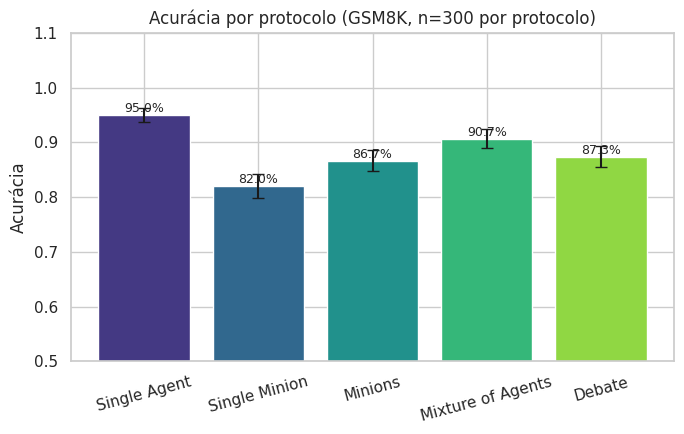

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
order = PROTOCOL_ORDER
acc = summary.loc[order, "accuracy"]
n = summary.loc[order, "n"]
# erro padrão de uma proporção binomial
err = np.sqrt(acc * (1 - acc) / n)

bars = ax.bar(
    [PROTOCOL_LABELS[p] for p in order],
    acc.values,
    yerr=err.values,
    capsize=4,
    color=sns.color_palette("viridis", len(order)),
)
ax.set_ylabel("Acurácia")
ax.set_ylim(0.5, 1.1)
ax.set_title("Acurácia por protocolo (GSM8K, n=300 por protocolo)")
for bar, value in zip(bars, acc.values):
    ax.annotate(f"{value:.1%}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "accuracy_by_protocol.png", dpi=150)
plt.show()

## Latência por protocolo

Distribuição do tempo de resposta (`latency_s`) por exemplo, em escala log para acomodar a variação entre protocolos simples e multiagente.

/tmp/ipykernel_2117182/4257328390.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([PROTOCOL_LABELS[p] for p in PROTOCOL_ORDER], rotation=15)


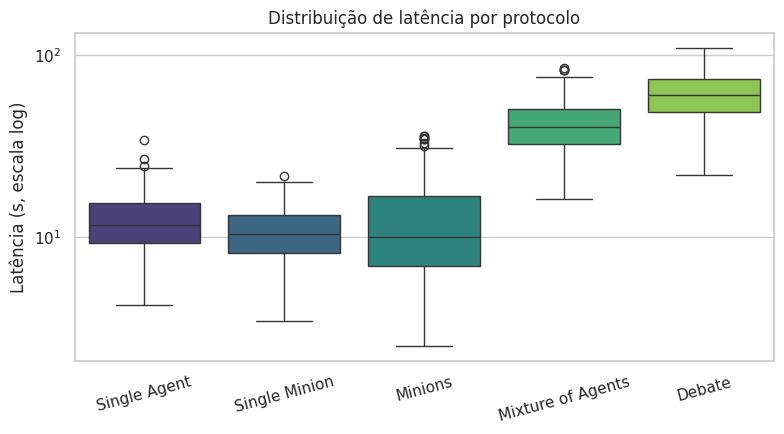

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(
    data=df, x="protocol", y="latency_s", order=PROTOCOL_ORDER,
    hue="protocol", legend=False, palette="viridis", ax=ax,
)
ax.set_yscale("log")
ax.set_xlabel("")
ax.set_ylabel("Latência (s, escala log)")
ax.set_xticklabels([PROTOCOL_LABELS[p] for p in PROTOCOL_ORDER], rotation=15)
ax.set_title("Distribuição de latência por protocolo")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "latency_by_protocol.png", dpi=150)
plt.show()

## Tokens totais por protocolo

Custo em tokens (`total_tokens`) consumido por exemplo.

/tmp/ipykernel_2117182/3740841007.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([PROTOCOL_LABELS[p] for p in PROTOCOL_ORDER], rotation=15)


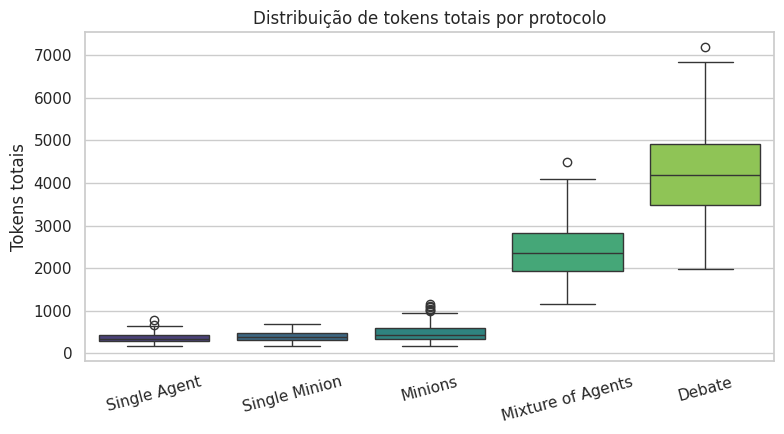

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(
    data=df, x="protocol", y="total_tokens", order=PROTOCOL_ORDER,
    hue="protocol", legend=False, palette="viridis", ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("Tokens totais")
ax.set_xticklabels([PROTOCOL_LABELS[p] for p in PROTOCOL_ORDER], rotation=15)
ax.set_title("Distribuição de tokens totais por protocolo")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "tokens_by_protocol.png", dpi=150)
plt.show()

## Número de chamadas ao modelo por protocolo

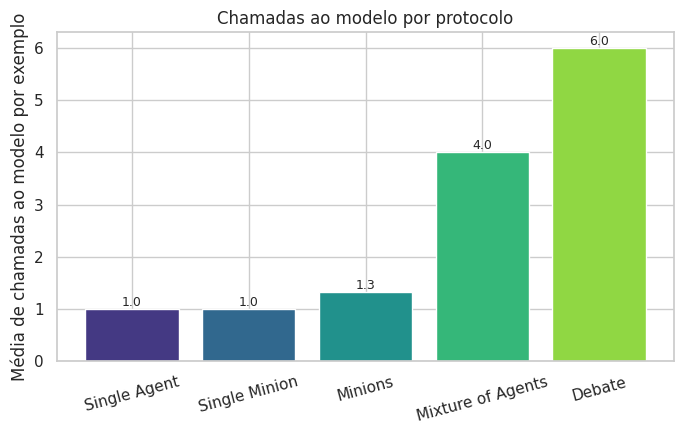

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
calls = summary.loc[PROTOCOL_ORDER, "n_model_calls_mean"]
bars = ax.bar(
    [PROTOCOL_LABELS[p] for p in PROTOCOL_ORDER], calls.values,
    color=sns.color_palette("viridis", len(PROTOCOL_ORDER)),
)
ax.set_ylabel("Média de chamadas ao modelo por exemplo")
ax.set_title("Chamadas ao modelo por protocolo")
for bar, value in zip(bars, calls.values):
    ax.annotate(f"{value:.1f}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_calls_by_protocol.png", dpi=150)
plt.show()

## Trade-off: acurácia vs. latência vs. custo em tokens

Cada ponto é um protocolo; a posição mostra acurácia x latência média, e o tamanho do ponto é proporcional ao custo médio em tokens.

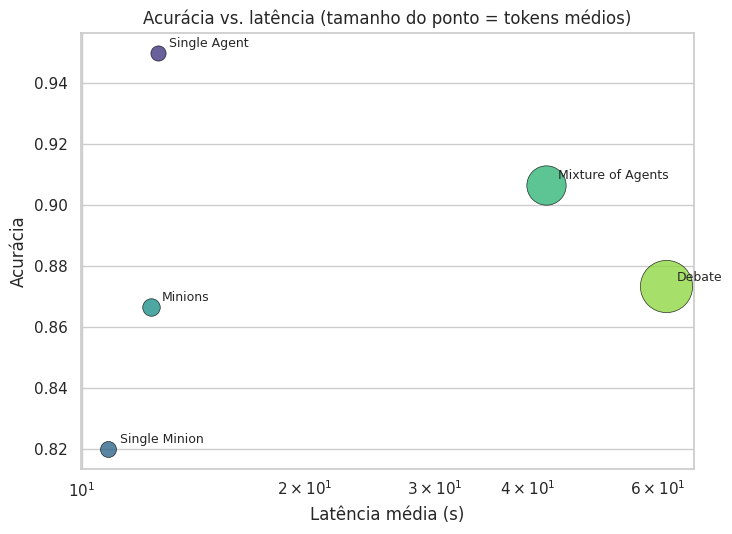

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
palette = sns.color_palette("viridis", len(PROTOCOL_ORDER))
for color, protocol in zip(palette, PROTOCOL_ORDER):
    row = summary.loc[protocol]
    ax.scatter(
        row["latency_mean_s"], row["accuracy"],
        s=row["total_tokens_mean"] / 3, color=color, alpha=0.8,
        edgecolor="black", linewidth=0.5,
        label=PROTOCOL_LABELS[protocol],
    )
    ax.annotate(
        PROTOCOL_LABELS[protocol],
        (row["latency_mean_s"], row["accuracy"]),
        textcoords="offset points", xytext=(8, 4), fontsize=9,
    )
ax.set_xlabel("Latência média (s)")
ax.set_ylabel("Acurácia")
ax.set_title("Acurácia vs. latência (tamanho do ponto = tokens médios)")
ax.set_xscale("log")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "tradeoff_accuracy_latency_tokens.png", dpi=150)
plt.show()

## Composição de tokens: master vs. minion

Para protocolos com hierarquia master/minion, mostra quanto do custo em tokens vem de cada papel.

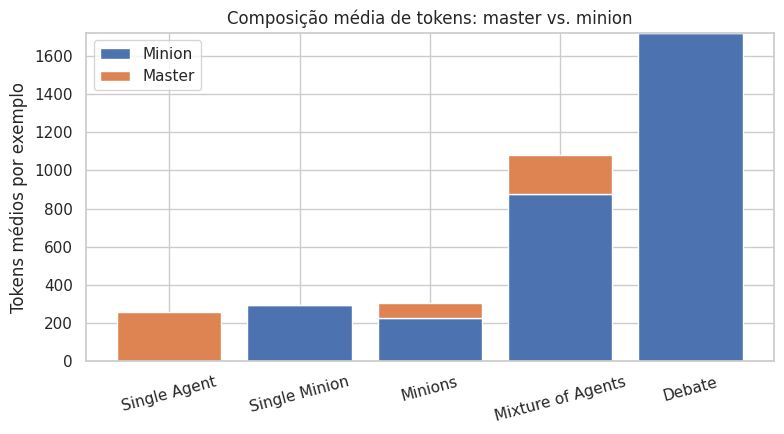

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
master = summary.loc[PROTOCOL_ORDER, "master_tokens_mean"]
minion = summary.loc[PROTOCOL_ORDER, "minion_tokens_mean"]
labels = [PROTOCOL_LABELS[p] for p in PROTOCOL_ORDER]

ax.bar(labels, minion.values, label="Minion", color="#4C72B0")
ax.bar(labels, master.values, bottom=minion.values, label="Master", color="#DD8452")
ax.set_ylabel("Tokens médios por exemplo")
ax.set_title("Composição média de tokens: master vs. minion")
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "token_composition_by_protocol.png", dpi=150)
plt.show()

## Uso do master por protocolo

Fração de exemplos em que o modelo master foi efetivamente chamado (`used_master=True`).

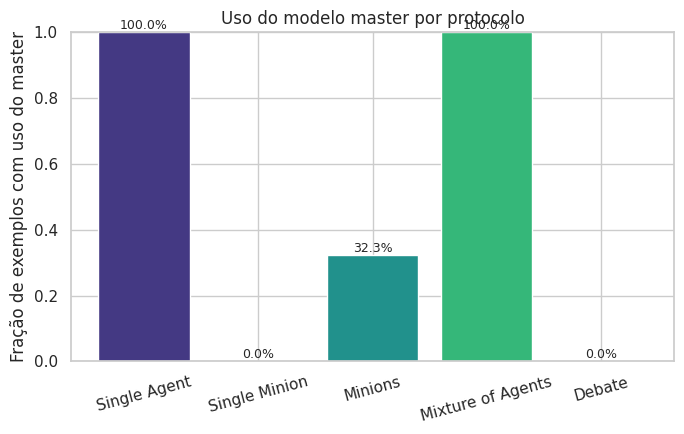

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))
frac = summary.loc[PROTOCOL_ORDER, "used_master_frac"]
bars = ax.bar(
    [PROTOCOL_LABELS[p] for p in PROTOCOL_ORDER], frac.values,
    color=sns.color_palette("viridis", len(PROTOCOL_ORDER)),
)
ax.set_ylabel("Fração de exemplos com uso do master")
ax.set_ylim(0, 1)
ax.set_title("Uso do modelo master por protocolo")
for bar, value in zip(bars, frac.values):
    ax.annotate(f"{value:.1%}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "used_master_fraction.png", dpi=150)
plt.show()

## Notas

- Todos os gráficos são gerados a partir dos `raw_*_v3.json`, sem depender dos arquivos `summary_v3.*`.
- As figuras também são salvas em `results/figures_v3/` em PNG, para uso fora do notebook.
- Como os 5 protocolos foram avaliados sobre exatamente as mesmas 300 perguntas (na mesma ordem), as
  comparações entre protocolos acima são pareadas por pergunta.